In [ ]:
# Import packages
import os
import pandas as pd
import geopandas as gpd
import rasterio 
from rasterio.plot import show
import ee
import geemap
import matplotlib.pyplot as plt
import pymannkendall as mk
import ipywidgets as widgets

In [5]:
# Open shp Ecuador
ecuador_shp_path = r"C:\Users\Francesco\Python\earthlab\Ecuador\data\ec_shp\ec.shp"
ecuador_gdf = gpd.read_file(ecuador_shp_path)

# Find Bolivar Province
print('Ecuador shp columns:', ecuador_gdf.columns)
print('Ecuador shp first rows:')
ecuador_gdf.head()

Ecuador shp columns: Index(['id', 'name', 'source', 'geometry'], dtype='object')
Ecuador shp first rows:


,id,name,source,geometry
0,ECE,Esmeraldas,https://simplemaps.com,"MULTIPOLYGON (((-78.47812 1.18712, -78.47831 1..."
1,ECC,Carchi,https://simplemaps.com,"POLYGON ((-78.44211 0.87194, -78.44714 0.87437..."
2,ECU,Sucumbios,https://simplemaps.com,"POLYGON ((-77.81408 0.34566, -77.79186 0.37099..."
3,ECD,Orellana,https://simplemaps.com,"POLYGON ((-77.29941 -0.05855, -77.28401 -0.047..."
4,ECY,Pastaza,https://simplemaps.com,"POLYGON ((-77.05165 -1.01038, -77.07198 -1.033..."


EPSG:4326
         minx      miny       maxx      maxy
18 -79.388379 -2.203689 -78.852649 -1.152281
POLYGON ((-79.13007402201852 -2.20368947718186, -79.12728349516446 -2.162761752759669, -79.13180518396472 -2.154338540364863, -79.13994421908582 -2.1465352583822774, -79.14922013970603 -2.145760157608147, -79.15870276761048 -2.1519614144427117, -79.16505896690337 -2.1580075009123507, -79.17164771365856 -2.161986651984419, -79.1831715563495 -2.162606732604619, -79.19500546064859 -2.162038325369444, -79.23549394559363 -2.154338540364863, -79.2198618217269 -2.1235392501852624, -79.21242041665035 -2.0895878836215798, -79.2052890701655 -2.073258192791147, -79.20552161181622 -2.0650415237865007, -79.21192949065275 -2.051037285506515, -79.24647518563232 -1.995485092581888, -79.278204515676 -1.9539372882750068, -79.27949642468617 -1.9448938452057438, -79.27510392885395 -1.9365739797328534, -79.26303748256076 -1.9285641545694903, -79.25851579604031 -1.9230864754394246, -79.24159176402561 -1.85668

<Axes: >

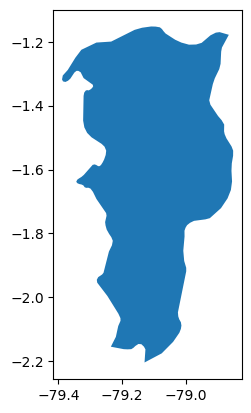

In [6]:
# Get the Bolivar province shp
bolivar_gdf = ecuador_gdf[ecuador_gdf['name'].str.contains('Bolivar', case=False, na=False)]
bolivar_gdf = bolivar_gdf.to_crs(epsg=4326)
print(bolivar_gdf.crs)
print(bolivar_gdf.bounds)
print(bolivar_gdf.geometry.iloc[0])
print('Bolivar geometry count:', len(bolivar_gdf))
bolivar_gdf.plot()

In [7]:
# Save Bolivar shp
folder_path = r'C:\Users\Francesco\Python\earthlab\Ecuador\data\Bolivar'
os.makedirs(folder_path, exist_ok=True)
out_path = os.path.join(folder_path, 'bolivar.shp')
bolivar_gdf.to_file(out_path)
print('Saved bolivar.shp:', out_path)

Saved bolivar.shp: C:\Users\Francesco\Python\earthlab\Ecuador\data\Bolivar\bolivar.shp


In [8]:
# GEE initialization
try:
    ee.Initialize()
    print('GEE initialized')
except Exception as e:
    ee.Authenticate()
    ee.Initialize()
    print('GEE authenticated and initialized')

GEE initialized


In [9]:
# Get the bolivar shp for GEE
bolivar = geemap.gdf_to_ee(bolivar_gdf)

# Time frame (2024)
start_date = '2024-01-01'
end_date = '2024-12-31'

# Mask function for Landsat
def mask_landsat_clouds(image):
    
    qa = image.select('QA_PIXEL')

    # Bits for cloud and shadow
    cloud_shadow_bit = 1 << 3
    snow_bit = 1 << 4
    cloud_bit = 1 << 5
    cirrus_bit = 1 << 7

    # Set bits to 0 (clear)
    mask = (qa.bitwiseAnd(cloud_shadow_bit).eq(0)
            .And(qa.bitwiseAnd(snow_bit).eq(0))
            .And(qa.bitwiseAnd(cloud_bit).eq(0))
            .And(qa.bitwiseAnd(cirrus_bit).eq(0)))
    
    # Apply mask
    image = image.updateMask(mask)

    # Scale values to reflectance values (multiply by 0.0000275 and add -0.2)
    image = image.multiply(0.0000275).add(-0.2)

    return image

# Load masked landsat images
landsat = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
           .filterBounds(bolivar)
           .filterDate(start_date, end_date)
           .map(mask_landsat_clouds))

# NDVI function
def add_ndvi(image, nir, red):
    
    ndvi = image.normalizedDifference([nir, red]).rename('NDVI')

    return image.addBands(ndvi)

# Create landsat images with NDVI
nir_landsat = 'SR_B5'
red_landsat = 'SR_B4'
landsat_ndvi = landsat.map(lambda img: add_ndvi(img, nir_landsat, red_landsat))

# Get the pixel median ndvi over each image (time)
median_ndvi = landsat_ndvi.select('NDVI').median().clip(bolivar)

# Export 2024 median NDVI to local GeoTIFF
out_folder = r"C:\Users\Francesco\Python\earthlab\Ecuador\data\Bolivar"
median_ndvi_2024_out_tif = os.path.join(out_folder, 'medianNDVIBolivar2024.tif')

geemap.ee_export_image(median_ndvi,
                       filename=median_ndvi_2024_out_tif,
                       scale=30,
                       region=bolivar.geometry(),
                       file_per_band=False)

print('Median NDVI 2024 on Bolivar Province exported locally: {median_NDVI_2024_out_tif}')

Generating URL ...
Please wait ...
Data downloaded to C:\Users\Francesco\Python\earthlab\Ecuador\data\Bolivar\medianNDVIBolivar2024.tif
Median NDVI 2024 on Bolivar Province exported locally: {median_NDVI_2024_out_tif}


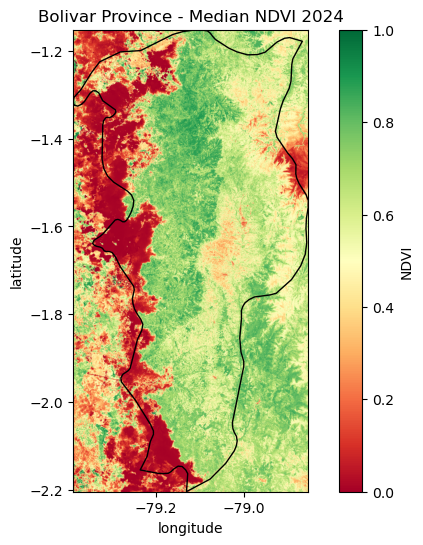

In [10]:
# Visualize the median NDVI 2024 for Bolivar Province
with rasterio.open(median_ndvi_2024_out_tif) as src:
    median_ndvi_2024 = src.read(1)
    median_ndvi_2024_extent = src.bounds

plt.figure(figsize=(8, 6))
median_ndvi_2024_plot = plt.imshow(median_ndvi_2024, cmap='RdYlGn', vmin=0, vmax=1, extent=(median_ndvi_2024_extent.left,
                                                                                            median_ndvi_2024_extent.right,
                                                                                            median_ndvi_2024_extent.bottom,
                                                                                            median_ndvi_2024_extent.top))
plt.colorbar(median_ndvi_2024_plot, label='NDVI')
plt.title('Bolivar Province - Median NDVI 2024')
plt.xlabel('longitude')
plt.ylabel('latitude')
# Overlay Bolivar Province boundary
bolivar_gdf.boundary.plot(ax=plt.gca(), color='black', linewidth=1)
plt.show()

In [11]:
# Visualize the median NDVI on GEE interactive map
# Create a new map instance
Map = geemap.Map()
# Center the map on bolivar with a zoom level 8
Map.centerObject(bolivar, 9)
# Map the median ndvi with a palette color
Map.addLayer(median_ndvi, {'min': 0,
                           'max': 1,
                           'palette': ['brown', 'yellow', 'green']},
                           'median NDVI')
# Map bolivar boundary
Map.addLayer(bolivar, {}, 'Bolivar Province boundary')
# Map it
Map

Map(center=[-1.6002983472888253, -79.10426536651003], controls=(WidgetControl(options=['position', 'transparen…

In [12]:
# NDVI TIME SERIES

start_year = 2013
end_year = 2024

years = list(range(start_year, end_year + 1))

def yearly_ndvi(year):

    start = ee.Date.fromYMD(year, 1, 1)
    end = ee.Date.fromYMD(year, 12, 31)

    coll = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
            .filterBounds(bolivar)
            .filterDate(start, end)
            .map(mask_landsat_clouds)
            .map(lambda img: add_ndvi(img, nir_landsat, red_landsat)))
    
    # Median on each pixel of the NDVI of each image in the time period
    median_ndvi_coll = coll.select('NDVI').median().clip(bolivar)

    # Mean of the median ndvi image
    mean_ndvi_dict = median_ndvi_coll.reduceRegion(reducer = ee.Reducer.mean(),
                                                   geometry = bolivar.geometry(),
                                                   scale = 30,
                                                   bestEffort = True)
    
    return {'year': year,
            'mean_NDVI': mean_ndvi_dict.get('NDVI').getInfo()}

# Build list of results
results = []
for y in years:
    results.append(yearly_ndvi(y))

# Convert the list into a dataframe
yearly_ndvi_df = pd.DataFrame(results)
print(yearly_ndvi_df)

    year  mean_NDVI
0   2013   0.553262
1   2014   0.627839
2   2015   0.511862
3   2016   0.552019
4   2017   0.587980
5   2018   0.565849
6   2019   0.559647
7   2020   0.516169
8   2021   0.535887
9   2022   0.550406
10  2023   0.547876
11  2024   0.542209


In [13]:
# Export yearly ndvi as a csv
yearly_ndvi_df.to_csv(rf"C:\Users\Francesco\Python\earthlab\Ecuador\data\Bolivar\yearly_mean_ndvi_bolivar_{start_year}_{end_year}.csv")
print(rf'NDVI time series saved: C:\Users\Francesco\Python\earthlab\Ecuador\data\Bolivar\yearly_mean_ndvi_bolivar_{start_year}_{end_year}.csv')

NDVI time series saved: C:\Users\Francesco\Python\earthlab\Ecuador\data\Bolivar\yearly_mean_ndvi_bolivar_2013_2024.csv


In [14]:
# Perform the Mann-Kendall Test on the time series

time_series_ndvi_df = pd.read_csv(r"C:\Users\Francesco\Python\earthlab\Ecuador\data\Bolivar\yearly_mean_ndvi_bolivar_2013_2024.csv")
time_series_ndvi_df = time_series_ndvi_df.sort_values('year')

mann_kendall_results = mk.original_test(time_series_ndvi_df['mean_NDVI'])

print('Mann-Kendall Test Results:\n')
print(mann_kendall_results)

Mann-Kendall Test Results:

Mann_Kendall_Test(trend='no trend', h=np.False_, p=np.float64(0.19261627432960227), z=np.float64(-1.302878414515109), Tau=np.float64(-0.30303030303030304), s=np.float64(-20.0), var_s=212.66666666666666, slope=np.float64(-0.003011570515923337), intercept=np.float64(0.5677761986229203))


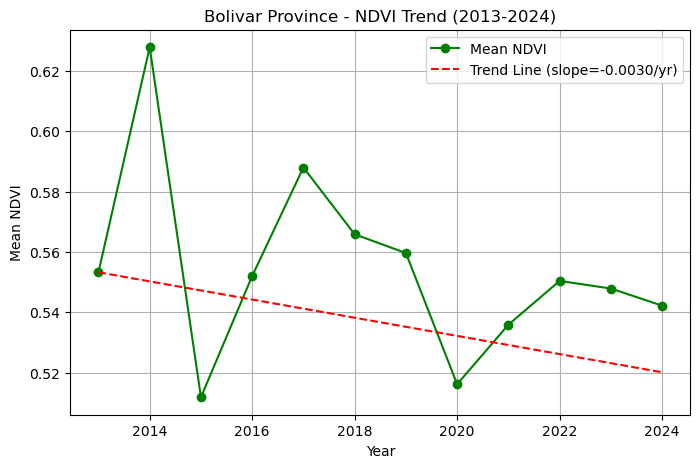

In [15]:
# Extract Sen's slope (trend magnitude)
slope = mann_kendall_results.slope
intercept = time_series_ndvi_df['mean_NDVI'].iloc[0] - slope * time_series_ndvi_df['year'].iloc[0]

# Compute the trend line
time_series_ndvi_df['trend_line'] = intercept + slope * time_series_ndvi_df['year']

# Plot NDVI and trend line
plt.figure(figsize=(8, 5))
plt.plot(time_series_ndvi_df['year'], time_series_ndvi_df['mean_NDVI'], 'o-', label='Mean NDVI', color='green')
plt.plot(time_series_ndvi_df['year'], time_series_ndvi_df['trend_line'], 'r--', label=f'Trend Line (slope={slope:.4f}/yr)')
plt.title('Bolivar Province - NDVI Trend (2013-2024)')
plt.xlabel('Year')
plt.ylabel('Mean NDVI')
plt.legend()
plt.grid(True)
plt.show()

In [16]:
# Pixel-wise NDVI Trend Mapping - Mann-Kendall and Pearson Correlation Test

# Built a list of median NDVI images
ndvi_images = []

for year in years:
    
    start = ee.Date.fromYMD(year, 1, 1)
    end = ee.Date.fromYMD(year, 12, 31)

    coll = (ee.ImageCollection('LANDSAT/LC08/C02/T1_L2')
            .filterBounds(bolivar)
            .filterDate(start, end)
            .map(mask_landsat_clouds)
            .map(lambda img: add_ndvi(img, nir_landsat, red_landsat)))
    
    median_ndvi = coll.select('NDVI').median().clip(bolivar).set('year', year)
    ndvi_images.append(median_ndvi)

# Create an Image Collection form the list of images
ndvi_coll = ee.ImageCollection(ndvi_images)

# Add the time band to each image
def add_time_band(img):
    year = ee.Number(img.get('year'))
    return img.addBands(ee.Image.constant(year).rename('year')).float()

ndvi_with_time = ndvi_coll.map(add_time_band)

# Perform the linear regression on the NDVI for each image(year)
trend = ndvi_with_time.select(['year', 'NDVI']).reduce(ee.Reducer.linearFit())

# Get the slope and the intercepts
slope = trend.select('scale').clip(bolivar)
intercept = trend.select('offset').clip(bolivar)

# Pearson Correlation (rho and p) between year and NDVI as a significance test
pearson = ndvi_with_time.select(['year', 'NDVI']).reduce(ee.Reducer.pearsonsCorrelation())
rho = pearson.select('correlation').clip(bolivar)
pval = pearson.select('p_value').clip(bolivar)

# Export slope and rho (NOT WORKING WITH THIS AOI BECAUSE THE EXPORT FILE EXCEED THE 50MB ALLOWED BY GEE)
slope_out_tif = os.path.join(out_folder, f'ndvi_slope_{start_year}_{end_year}.tif')
rho_out_tif = os.path.join(out_folder, f'ndvi_rho_{start_year}_{end_year}.tif')

geemap.ee_export_image(slope,
                       filename=slope_out_tif,
                       scale=40,
                       region=bolivar.geometry(),
                       file_per_band=False)

print(f'NDVI slope {start_year} - {end_year} exported: {slope_out_tif}')

geemap.ee_export_image(rho,
                       filename=rho_out_tif,
                       scale=40,
                       region=bolivar.geometry(),
                       file_per_band=False)

print(f'NDVI rho {start_year} - {end_year} exported: {rho_out_tif}')

Generating URL ...
Please wait ...
Data downloaded to C:\Users\Francesco\Python\earthlab\Ecuador\data\Bolivar\ndvi_slope_2013_2024.tif
NDVI slope 2013 - 2024 exported: C:\Users\Francesco\Python\earthlab\Ecuador\data\Bolivar\ndvi_slope_2013_2024.tif
Generating URL ...
Please wait ...
Data downloaded to C:\Users\Francesco\Python\earthlab\Ecuador\data\Bolivar\ndvi_rho_2013_2024.tif
NDVI rho 2013 - 2024 exported: C:\Users\Francesco\Python\earthlab\Ecuador\data\Bolivar\ndvi_rho_2013_2024.tif


RASTER INFO:
Raster CRS: EPSG:4326
Raster bounds: BoundingBox(left=-79.38843357100589, bottom=-2.20374705500201, right=-78.85231900944336, top=-1.1519995203548743)
Raster shape: (2927, 1492)

BOUNDARY INFO:
Boundary CRS: GEOGCS["WGS 84",DATUM["WGS_1984",SPHEROID["WGS 84",6378137,298.257223563,AUTHORITY["EPSG","7030"]],AUTHORITY["EPSG","6326"]],PRIMEM["Greenwich",0,AUTHORITY["EPSG","8901"]],UNIT["degree",0.0174532925199433,AUTHORITY["EPSG","9122"]],AXIS["Latitude",NORTH],AXIS["Longitude",EAST],AUTHORITY["EPSG","4326"]]
Boundary bounds: [-79.38837867  -2.20368948 -78.8526491   -1.15228079]
Number of features: 1


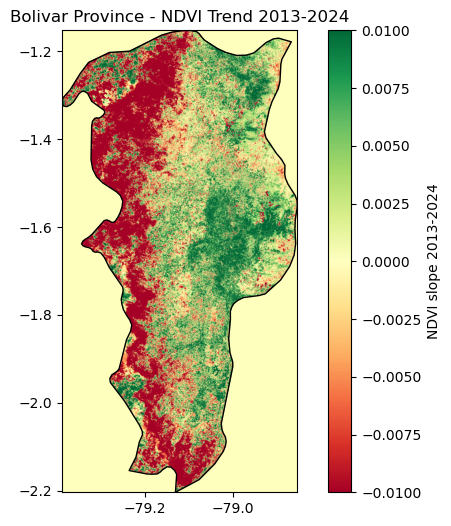

In [17]:
# Visualize NDVI slope 2013-2024
with rasterio.open(slope_out_tif) as src:
    ndvi_slope = src.read(1)
    ndvi_slope_extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    #ndvi_slope_extent = src.bounds

    print("RASTER INFO:")
    print(f"Raster CRS: {src.crs}")
    print(f"Raster bounds: {src.bounds}")
    print(f"Raster shape: {ndvi_slope.shape}")

    bolivar_gdf = bolivar_gdf.to_crs(src.crs)

    print("\nBOUNDARY INFO:")
    print(f"Boundary CRS: {bolivar_gdf.crs}")
    print(f"Boundary bounds: {bolivar_gdf.total_bounds}")
    print(f"Number of features: {len(bolivar_gdf)}")


plt.figure(figsize=(8, 6))
ndvi_slope_plot = plt.imshow(ndvi_slope,
                             cmap='RdYlGn',
                             vmin=-0.01,
                             vmax=0.01,
                             extent=ndvi_slope_extent,
                             origin='upper')
plt.colorbar(ndvi_slope_plot,
             label=f'NDVI slope {start_year}-{end_year}')
plt.title(f'Bolivar Province - NDVI Trend {start_year}-{end_year}')
bolivar_gdf.boundary.plot(ax=plt.gca(),
                      color='black',
                      linewidth=1)
plt.show()

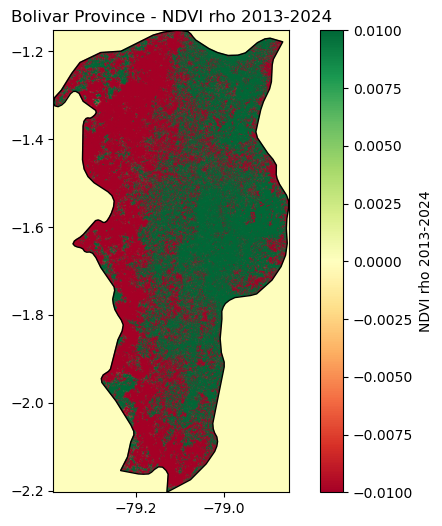

In [18]:
# Visualize NDVI rho 2013-2024
with rasterio.open(rho_out_tif) as src:
    ndvi_rho = src.read(1)
    ndvi_rho_extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]

plt.figure(figsize=(8, 6))
ndvi_rho_plot = plt.imshow(ndvi_rho,
                           cmap='RdYlGn',
                           vmin=-0.01,
                           vmax=0.01,
                           extent=ndvi_slope_extent,
                           origin='upper')
plt.colorbar(ndvi_rho_plot,
             label=f'NDVI rho {start_year}-{end_year}')
plt.title(f'Bolivar Province - NDVI rho {start_year}-{end_year}')
bolivar_gdf.boundary.plot(ax=plt.gca(),
                      color='black',
                      linewidth=1)
plt.show()

In [19]:
# Visualize NDVI slope and rho with GEE interactive map
Map = geemap.Map()
Map.centerObject(bolivar, 9)
Map.addLayer(slope, {'min': -0.02,
                     'max': 0.02,
                    'palette': ['red', 'white', 'green']}, 'NDVI Trend (Slope per Year)')
Map.addLayer(bolivar, {}, 'Bolivar Province Boundary')
Map.addLayer(rho, {'min': -1,
                   'max': 1,
                   'palette': ['red', 'white', 'green']}, 'Pearson rho')
Map

Map(center=[-1.6002983472888253, -79.10426536651003], controls=(WidgetControl(options=['position', 'transparen…